In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to your dataset
data_path = "/content/drive/MyDrive/NewFolder/CP-AnemiC"

print("Dataset path:", data_path)


Dataset path: /content/drive/MyDrive/NewFolder/CP-AnemiC


In [ ]:
!ls "/content/drive/MyDrive/NewFolder/CP-AnemiC"


Anemia_Data_Collection_Sheet.xlsx  manifest_conjunctiva_binary.csv
Anemic				   Non-anemic


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from skimage.color import rgb2lab
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import pandas as pd

# Configuration
ROOT = Path("/content/drive/MyDrive/NewFolder/CP-AnemiC")
IMG_SIZE = 200  # Following paper methodology
BATCH_SIZE = 32
SEED = 42

print(f"Dataset root: {ROOT}")


Dataset root: /content/drive/MyDrive/NewFolder/CP-AnemiC


In [ ]:
# # Load dataset with proper splits
# full_ds = tf.keras.utils.image_dataset_from_directory(
#     ROOT,
#     image_size=(IMG_SIZE, IMG_SIZE),
#     batch_size=None,
#     label_mode='int',
#     shuffle=True,
#     seed=SEED
# )

# # Convert to numpy arrays
# images = []
# labels = []
# for image, label in full_ds:
#     images.append(image.numpy())
#     labels.append(label.numpy())

# images = np.array(images)
# labels = np.array(labels)

images = np.load("/content/drive/MyDrive/DCGAN/images.npy")
labels = np.load("/content/drive/MyDrive/DCGAN/labels.npy")

print("✅ Loaded dataset from Drive")
print(images.shape, labels.shape)


print(f"Total images: {len(images)}")
print(f"Image shape: {images[0].shape}")
print(f"Labels distribution: {np.bincount(labels)}")


✅ Loaded dataset from Drive
(710, 200, 200, 3) (710,)
Total images: 710
Image shape: (200, 200, 3)
Labels distribution: [424 286]


In [ ]:
# import numpy as np

# # Save arrays once
# np.save("/content/drive/MyDrive/DCGAN/images.npy", images)
# np.save("/content/drive/MyDrive/DCGAN/labels.npy", labels)

# print("✅ Saved preprocessed dataset to Drive")


✅ Saved preprocessed dataset to Drive


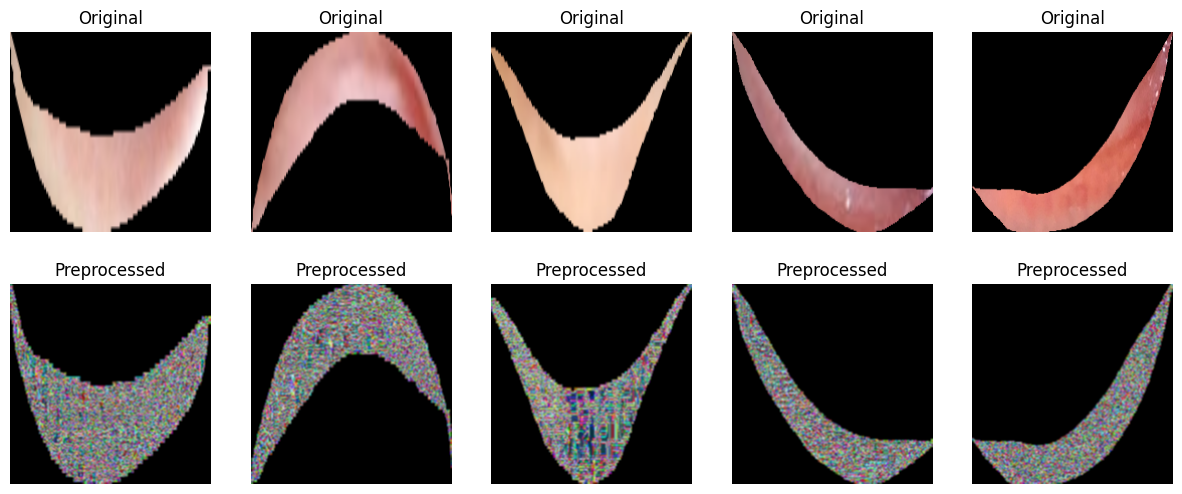

In [ ]:
def preprocess_image(image):
    """
    Apply preprocessing as per paper methodology:
    1. Histogram equalization
    2. Gaussian blur
    3. Convert to CIELAB color space
    """
    # Convert to uint8 if needed
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)

    # Histogram equalization on each RGB channel
    img_eq = np.zeros_like(image)
    for i in range(3):
        img_eq[:, :, i] = cv2.equalizeHist(image[:, :, i])

    # Gaussian blur to reduce reflections
    img_blur = cv2.GaussianBlur(img_eq, (3, 3), 0)

    # Convert to CIELAB color space
    img_lab = rgb2lab(img_blur / 255.0)

    return img_blur, img_lab

# Apply preprocessing to all images
preprocessed_images = []
lab_images = []

for img in images:
    proc_img, lab_img = preprocess_image(img)
    preprocessed_images.append(proc_img)
    lab_images.append(lab_img)

preprocessed_images = np.array(preprocessed_images)
lab_images = np.array(lab_images)

# Visualize preprocessing results
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(images[i].astype(np.uint8))
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(preprocessed_images[i])
    axes[1, i].set_title('Preprocessed')
    axes[1, i].axis('off')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# First split: 80% temp (train+val), 20% test
img_temp, img_test, y_temp, y_test = train_test_split(
    preprocessed_images, labels,
    test_size=0.2, random_state=SEED, stratify=labels
)

# Second split: from 80%, create 70% train and 10% val
img_train, img_val, y_train, y_val = train_test_split(
    img_temp, y_temp,
    test_size=0.125, random_state=SEED, stratify=y_temp
)

print(f"Train: {img_train.shape}, Val: {img_val.shape}, Test: {img_test.shape}")
print(f"Labels - Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

# Safety checks
assert len(img_train) == len(y_train)
assert len(img_val) == len(y_val)
assert len(img_test) == len(y_test)

print("✅ DL dataset aligned correctly!")


Train: (497, 200, 200, 3), Val: (71, 200, 200, 3), Test: (142, 200, 200, 3)
Labels - Train: 497, Val: 71, Test: 142
✅ DL dataset aligned correctly!


In [ ]:
# ===============================
# CHUNK 2: DCGAN Architecture
# ===============================
print("🧠 Building DCGAN architecture...")

def build_dcgan_generator(latent_dim=100):
    """Generator: DCGAN paper + tweaks"""
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(latent_dim,)),  # ✅ Fixed Input layer
        tf.keras.layers.Dense(4*4*512, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Reshape((4, 4, 512)),

        # 8x8
        tf.keras.layers.Conv2DTranspose(256, (5,5), strides=(2,2), padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),

        # 16x16
        tf.keras.layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),

        # 32x32
        tf.keras.layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),

        # 64x64 → final
        tf.keras.layers.Conv2DTranspose(3, (5,5), strides=(2,2), padding='same',
                                        use_bias=False, activation='tanh')
    ], name="DCGAN_Generator")
    return model


def build_dcgan_discriminator(img_size=64):
    """Discriminator: DCGAN paper + tweaks"""
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(img_size, img_size, 3)),  # ✅ Fixed Input layer

        # 64x64 → 32x32
        tf.keras.layers.Conv2D(64, (5,5), strides=(2,2), padding='same'),
        tf.keras.layers.LeakyReLU(negative_slope=0.2),  # ✅ fixed deprecation
        tf.keras.layers.Dropout(0.3),

        # 32x32 → 16x16
        tf.keras.layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        tf.keras.layers.LeakyReLU(negative_slope=0.2),
        tf.keras.layers.Dropout(0.3),

        # 16x16 → 8x8
        tf.keras.layers.Conv2D(256, (5,5), strides=(2,2), padding='same'),
        tf.keras.layers.LeakyReLU(negative_slope=0.2),
        tf.keras.layers.Dropout(0.3),

        # 8x8 → 4x4
        tf.keras.layers.Conv2D(512, (5,5), strides=(2,2), padding='same'),
        tf.keras.layers.LeakyReLU(negative_slope=0.2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)  # from_logits=True → no activation
    ], name="DCGAN_Discriminator")
    return model

print("✅ DCGAN architecture defined")


🧠 Building DCGAN architecture...
✅ DCGAN architecture defined


In [ ]:
# ===============================
# CHUNK 3: Data Preparation & Training Setup
# ===============================
print("⚙️ Preparing data for DCGAN training...")

DCGAN_IMG_SIZE = 64  # ✅ define explicitly

def resize_images_for_dcgan(images, target_size=(DCGAN_IMG_SIZE, DCGAN_IMG_SIZE)):
    """Resize images to target size for DCGAN"""
    resized_images = []
    for img in images:
        resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        resized_images.append(resized_img)
    return np.array(resized_images)

# Split training data by class
class_0_mask = (y_train == 0)
class_1_mask = (y_train == 1)

class_0_images = img_train[class_0_mask]
class_1_images = img_train[class_1_mask]

print(f"Class 0 (Non-anemic): {len(class_0_images)} images")
print(f"Class 1 (Anemic): {len(class_1_images)} images")

# Prepare DCGAN data (resize + normalize to [-1, 1])
def prepare_dcgan_data(images):
    """Prepare images for DCGAN training"""
    images_64 = resize_images_for_dcgan(images)
    images_64 = (images_64.astype('float32') / 127.5) - 1.0
    return images_64

class_0_dcgan = prepare_dcgan_data(class_0_images)
class_1_dcgan = prepare_dcgan_data(class_1_images)

print("✅ Data preparation complete")

# -------------------------------
# Loss functions
# -------------------------------
def generator_loss(fake_output):
    return tf.keras.losses.BinaryCrossentropy(from_logits=True)(
        tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss  # ✅ fixed bug

print("✅ Training setup complete")


⚙️ Preparing data for DCGAN training...
Class 0 (Non-anemic): 297 images
Class 1 (Anemic): 200 images
✅ Data preparation complete
✅ Training setup complete


🔥 Training with optimized function...

--- Training DCGAN for Non-anemic ---
Epoch 000/50 | Gen: 1.5178 | Disc: 0.5800


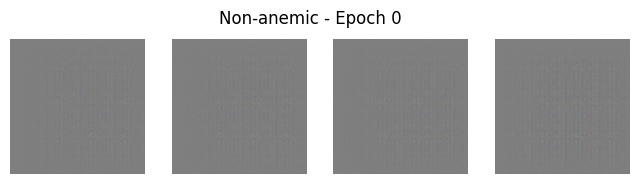

Epoch 010/50 | Gen: 0.7670 | Disc: 1.1301
Epoch 020/50 | Gen: 0.8939 | Disc: 1.1304
Epoch 030/50 | Gen: 1.2898 | Disc: 0.9191
Epoch 040/50 | Gen: 1.2489 | Disc: 1.1179
Epoch 049/50 | Gen: 1.1592 | Disc: 0.9101


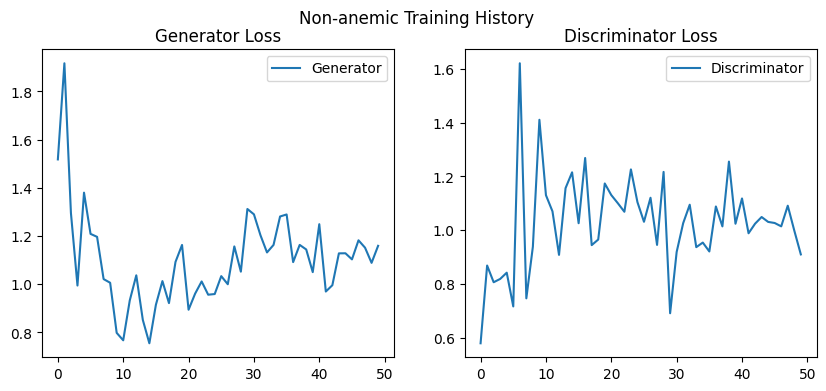

✅ Non-anemic DCGAN training complete

--- Training DCGAN for Anemic ---
Epoch 000/50 | Gen: 1.2318 | Disc: 0.6603


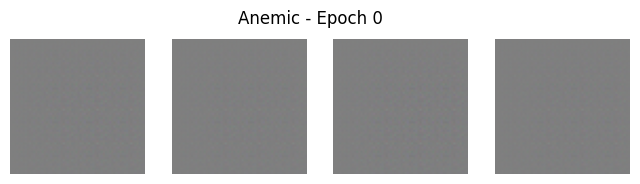

Epoch 010/50 | Gen: 0.8188 | Disc: 1.2995
Epoch 020/50 | Gen: 0.7428 | Disc: 1.1429
Epoch 030/50 | Gen: 1.0052 | Disc: 1.0599
Epoch 040/50 | Gen: 1.0786 | Disc: 1.1286
Epoch 049/50 | Gen: 1.0504 | Disc: 1.0863


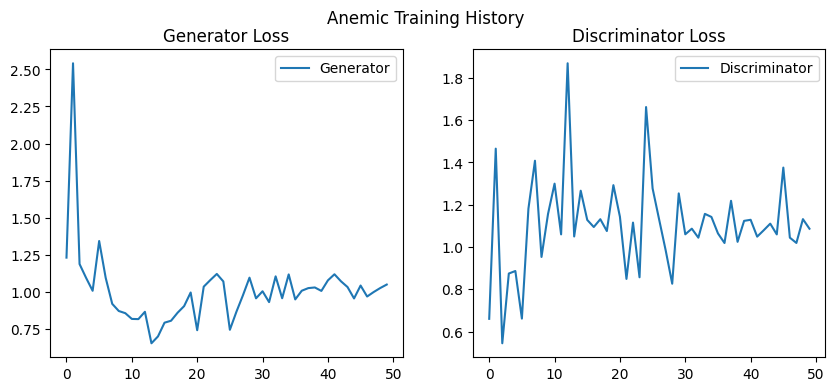

✅ Anemic DCGAN training complete


In [ ]:
  # ===============================
  # OPTIMIZED DCGAN Training (Replace your current function)
  # ===============================

  def train_dcgan_class_specific_optimized(class_images, class_name, epochs=100):
      """Optimized DCGAN training - faster and more stable"""
      print(f"\n--- Training DCGAN for {class_name} ---")

      # Create fresh models
      class_generator = build_dcgan_generator(LATENT_DIM)
      class_discriminator = build_dcgan_discriminator(DCGAN_IMG_SIZE)

      # Optimizers
      gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
      disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

      # SIMPLIFIED dataset (remove prefetch for now)
      dataset = tf.data.Dataset.from_tensor_slices(class_images)
      dataset = dataset.shuffle(1000).batch(DCGAN_BATCH_SIZE)

      # Training history
      gen_losses, disc_losses = [], []

      for epoch in range(epochs):
          epoch_gen, epoch_disc = [], []

          # Remove tqdm for speed - use simple loop
          for image_batch in dataset:
              noise = tf.random.normal([image_batch.shape[0], LATENT_DIM])

              with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
                  # Generate images
                  generated_images = class_generator(noise, training=True)

                  # Discriminate
                  real_output = class_discriminator(image_batch, training=True)
                  fake_output = class_discriminator(generated_images, training=True)

                  # Losses
                  gen_loss = generator_loss(fake_output)
                  disc_loss = discriminator_loss(real_output, fake_output)

              # Gradients
              gen_grads = gen_tape.gradient(gen_loss, class_generator.trainable_variables)
              disc_grads = disc_tape.gradient(disc_loss, class_discriminator.trainable_variables)

              # Apply gradients
              gen_optimizer.apply_gradients(zip(gen_grads, class_generator.trainable_variables))
              disc_optimizer.apply_gradients(zip(disc_grads, class_discriminator.trainable_variables))

              epoch_gen.append(gen_loss.numpy())
              epoch_disc.append(disc_loss.numpy())

          # Store epoch losses
          avg_gen, avg_disc = np.mean(epoch_gen), np.mean(epoch_disc)
          gen_losses.append(avg_gen)
          disc_losses.append(avg_disc)

          # Print progress (less frequent to reduce overhead)
          if epoch % 10 == 0 or epoch == epochs - 1:
              print(f"Epoch {epoch:03d}/{epochs} | Gen: {avg_gen:.4f} | Disc: {avg_disc:.4f}")

              # Generate samples (less frequent)
              if epoch % 50 == 0:
                  noise = tf.random.normal([4, LATENT_DIM])
                  samples = class_generator(noise, training=False)
                  samples = (samples + 1) / 2.0

                  plt.figure(figsize=(8, 2))
                  for i in range(4):
                      plt.subplot(1, 4, i+1)
                      plt.imshow(samples[i].numpy())
                      plt.axis('off')
                  plt.suptitle(f"{class_name} - Epoch {epoch}")
                  plt.show()

      # Plot training history at the end
      plt.figure(figsize=(10, 4))
      plt.subplot(1, 2, 1)
      plt.plot(gen_losses, label='Generator')
      plt.title('Generator Loss')
      plt.legend()

      plt.subplot(1, 2, 2)
      plt.plot(disc_losses, label='Discriminator')
      plt.title('Discriminator Loss')
      plt.legend()

      plt.suptitle(f'{class_name} Training History')
      plt.show()

      print(f"✅ {class_name} DCGAN training complete")
      return class_generator

  # ===============================
  # TRAIN WITH OPTIMIZED FUNCTION (Fewer epochs to test)
  # ===============================
  print("🔥 Training with optimized function...")

  # Train with fewer epochs first to test
  generator_class_0 = train_dcgan_class_specific_optimized(class_0_dcgan, "Non-anemic", epochs=50)
  generator_class_1 = train_dcgan_class_specific_optimized(class_1_dcgan, "Anemic", epochs=50)

🧪 Testing Non-anemic generator...


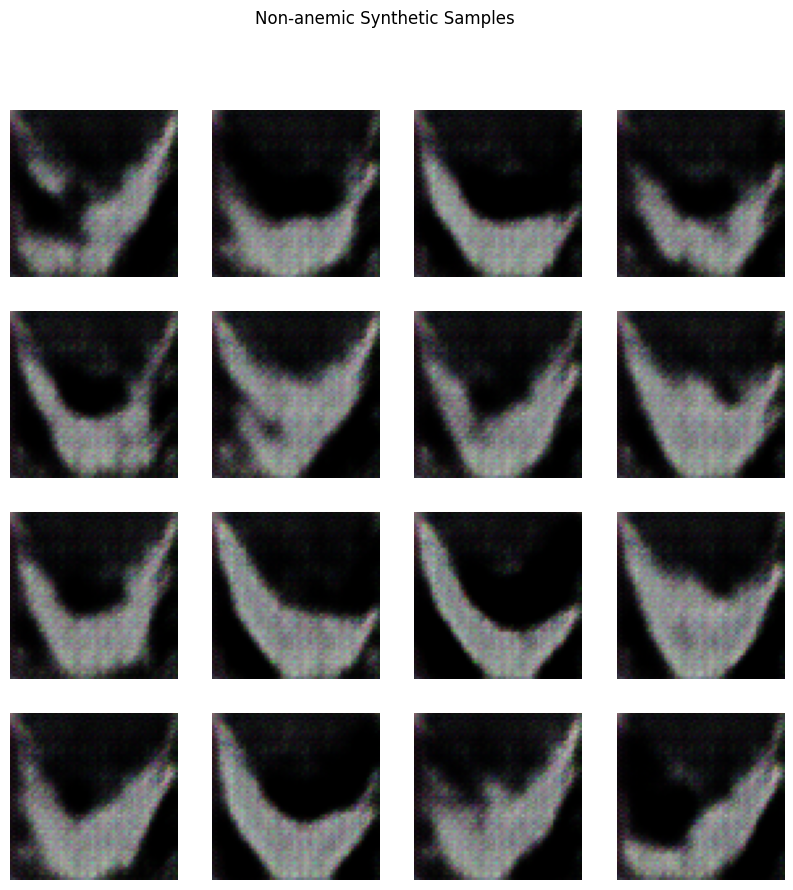

In [ ]:
# Test the trained non-anemic generator
print("🧪 Testing Non-anemic generator...")
test_noise = tf.random.normal([16, LATENT_DIM])
test_samples = generator_class_1(test_noise, training=False)
test_samples = (test_samples + 1) / 2.0

# Display samples
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(test_samples[i].numpy())
    plt.axis('off')
plt.suptitle('Non-anemic Synthetic Samples')
plt.show()

In [ ]:
# ===============================
# GENERATE BALANCED SYNTHETIC DATASET
# ===============================

def generate_synthetic_images(generator, num_images):
    """Generate synthetic images using trained generator"""
    print(f"Generating {num_images} synthetic images...")

    batch_size = 32
    synthetic_images = []
    num_batches = (num_images + batch_size - 1) // batch_size

    for i in range(num_batches):
        current_batch_size = min(batch_size, num_images - i * batch_size)
        noise = tf.random.normal([current_batch_size, LATENT_DIM])
        generated_batch = generator(noise, training=False)
        generated_batch = (generated_batch + 1) / 2.0  # Convert to [0,1]
        synthetic_images.append(generated_batch.numpy())

        if i % 10 == 0:
            print(f"Generated batch {i+1}/{num_batches}")

    return np.concatenate(synthetic_images, axis=0)

def preprocess_synthetic_batch(synthetic_images):
    """Preprocess synthetic images to match real image format"""
    processed = np.clip(synthetic_images, 0, 1)

    # Resize if needed to match original dataset
    if processed.shape[1:3] != img_train.shape[1:3]:
        processed = tf.image.resize(processed, [img_train.shape[1], img_train.shape[2]])
        processed = processed.numpy()

    return processed.astype(np.float32)

print("🌈 Generating balanced synthetic data...")

# Calculate how many synthetic images needed
total_target = 4315  # Paper's target
current_total = len(img_train)
synthetic_needed = total_target - current_total
synthetic_per_class = synthetic_needed // 2

print(f"Generating {synthetic_per_class} synthetic images per class")

# Generate synthetic images for both classes
synthetic_0 = generate_synthetic_images(generator_class_0, synthetic_per_class)
synthetic_1 = generate_synthetic_images(generator_class_1, synthetic_per_class)

print(f"✅ Generated: {len(synthetic_0)} Class 0 + {len(synthetic_1)} Class 1")

# Preprocess synthetic images (same pipeline as real images)
synthetic_0_processed = preprocess_synthetic_batch(synthetic_0)
synthetic_1_processed = preprocess_synthetic_batch(synthetic_1)

# Create augmented dataset
X_train_augmented = np.concatenate([img_train, synthetic_0_processed, synthetic_1_processed])
y_train_augmented = np.concatenate([y_train, np.zeros(len(synthetic_0_processed)), np.ones(len(synthetic_1_processed))])

print(f"🎉 AUGMENTATION COMPLETE! Total: {len(X_train_augmented)} images")

🌈 Generating balanced synthetic data...
Generating 1909 synthetic images per class
Generating 1909 synthetic images...
Generated batch 1/60
Generated batch 11/60
Generated batch 21/60
Generated batch 31/60
Generated batch 41/60
Generated batch 51/60
Generating 1909 synthetic images...
Generated batch 1/60
Generated batch 11/60
Generated batch 21/60
Generated batch 31/60
Generated batch 41/60
Generated batch 51/60
✅ Generated: 1909 Class 0 + 1909 Class 1
🎉 AUGMENTATION COMPLETE! Total: 4315 images


In [ ]:
# ===============================
# QUICK SAVE VERSION
# ===============================

import os
import numpy as np
from PIL import Image

# Create main folder
drive_path = "/content/drive/MyDrive/DCGAN"
os.makedirs(drive_path, exist_ok=True)

print("💾 Quick saving to drive...")

# 1. Save augmented dataset as numpy arrays
np.save(os.path.join(drive_path, "X_train_augmented.npy"), X_train_augmented)
np.save(os.path.join(drive_path, "y_train_augmented.npy"), y_train_augmented)

# 2. Save synthetic images as numpy arrays (faster than individual PNGs)
np.save(os.path.join(drive_path, "synthetic_class_0.npy"), synthetic_0_processed)
np.save(os.path.join(drive_path, "synthetic_class_1.npy"), synthetic_1_processed)

# 3. Save generators
generator_class_0.save(os.path.join(drive_path, "generator_class_0.h5"))
generator_class_1.save(os.path.join(drive_path, "generator_class_1.h5"))

# 4. Save dataset summary
with open(os.path.join(drive_path, "summary.txt"), 'w') as f:
    f.write(f"Total augmented samples: {len(X_train_augmented)}\n")
    f.write(f"Original samples: {len(img_train)}\n")
    f.write(f"Synthetic class 0: {len(synthetic_0_processed)}\n")
    f.write(f"Synthetic class 1: {len(synthetic_1_processed)}\n")
    f.write(f"Class 0 total: {np.sum(y_train_augmented == 0)}\n")
    f.write(f"Class 1 total: {np.sum(y_train_augmented == 1)}\n")

print("✅ Quick save complete!")
print(f"Files saved to: {drive_path}")


💾 Quick saving to drive...


✅ Quick save complete!
Files saved to: /content/drive/MyDrive/DCGAN


In [ ]:
# import os

# # Create folder in Drive if it doesn't exist
# save_dir = "/content/drive/MyDrive/DCGAN"
# os.makedirs(save_dir, exist_ok=True)

# # Save synthetic dataset
# np.save(f"{save_dir}/synthetic_images.npy", synthetic_images)

# print("✅ Synthetic images saved successfully at:", f"{save_dir}/synthetic_images.npy")


In [ ]:
# # Save models
# generator.save(f"{save_dir}/generator_model.h5")
# discriminator.save(f"{save_dir}/discriminator_model.h5")

# print("✅ GAN models saved successfully")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

# ==========================================================
# LOAD FINAL AUGMENTED DATASET
# ==========================================================

# Set your drive path (adjust if needed)
DRIVE_PATH = "/content/drive/MyDrive/DCGAN"

def load_final_augmented_dataset(drive_path=DRIVE_PATH):
    """
    Load the final augmented dataset with original variables names
    """
    try:
        # Load the main augmented dataset
        X_train_augmented = np.load(f"{drive_path}/X_train_augmented.npy")
        y_train_augmented = np.load(f"{drive_path}/y_train_augmented.npy")

        print(f"✅ Loaded X_train_augmented: {X_train_augmented.shape}")
        print(f"✅ Loaded y_train_augmented: {y_train_augmented.shape}")
        print(f"   Class 0: {np.sum(y_train_augmented == 0)}")
        print(f"   Class 1: {np.sum(y_train_augmented == 1)}")

        return X_train_augmented, y_train_augmented

    except FileNotFoundError:
        print(f"❌ Files not found in {drive_path}")
        return None, None

# Load your final augmented dataset
X_train_augmented, y_train_augmented = load_final_augmented_dataset()


✅ Loaded X_train_augmented: (4315, 200, 200, 3)
✅ Loaded y_train_augmented: (4315,)
   Class 0: 2206
   Class 1: 2109


In [ ]:
# ==========================================================
# DATA PREPARATION WITH TRAIN/VALIDATION SPLIT (THE MISSING CELL)
# ==========================================================
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np

def prepare_final_dataset_with_split(X_train_augmented, y_train_augmented, batch_size=32, val_split=0.2):
    """
    This function takes your full augmented dataset and splits it into
    a training set and a validation set.
    """
    print("📊 Preparing final augmented dataset...")

    # Ensure your images are the right shape for the model (224x224x3)
    if X_train_augmented.shape[1:3] != (224, 224):
        print("Resizing images to 224x224...")
        X_train_final = tf.image.resize(X_train_augmented, [224, 224]).numpy()
    else:
        X_train_final = X_train_augmented.copy()

    # Ensure images have 3 channels (RGB)
    if X_train_final.shape[-1] == 1:
        X_train_final = tf.image.grayscale_to_rgb(X_train_final).numpy()

    # Normalize pixel values to [0, 1] for InceptionV3
    if X_train_final.max() > 1.0:
        print("Normalizing pixel values to [0, 1]...")
        X_train_final = X_train_final / 255.0

    print(f"Final data shape: {X_train_final.shape}")
    print(f"Class distribution: Class 0: {np.sum(y_train_augmented == 0)}, Class 1: {np.sum(y_train_augmented == 1)}")

    # --- THIS IS WHERE img_val_224 and y_val ARE CREATED ---
    print(f"\n🔄 Creating train/validation split...")
    X_train_split, img_val_224, y_train_split, y_val = train_test_split(
        X_train_final,
        y_train_augmented,
        test_size=val_split,
        stratify=y_train_augmented,
        random_state=42
    )

    print(f"✅ Train split: {X_train_split.shape} | Val split: {img_val_224.shape}")

    # Create TensorFlow Dataset for efficient training
    train_ds_final = tf.data.Dataset.from_tensor_slices((X_train_split, y_train_split))
    train_ds_final = train_ds_final.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds_final, X_train_split, img_val_224, y_val

# --- EXECUTE THE FUNCTION TO CREATE THE VARIABLES ---
# Make sure X_train_augmented and y_train_augmented are loaded or created before this line
train_ds_final, X_train_final, img_val_224, y_val = prepare_final_dataset_with_split(
    X_train_augmented,
    y_train_augmented,
    batch_size=32
)

print("✅ Data preprocessing and splitting complete!")
print(f"✅ `img_val_224` and `y_val` are now ready for training.")


📊 Preparing final augmented dataset...
Resizing images to 224x224...
Normalizing pixel values to [0, 1]...
Final data shape: (4315, 224, 224, 3)
Class distribution: Class 0: 2206, Class 1: 2109

🔄 Creating train/validation split...
✅ Train split: (3452, 224, 224, 3) | Val split: (863, 224, 224, 3)
✅ Data preprocessing and splitting complete!
✅ `img_val_224` and `y_val` are now ready for training.


In [ ]:
# ==========================================================
# CHUNK 1: MODEL DEFINITIONS (UPDATED WITH MORE REGULARIZATION)
# ==========================================================

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow as tf

def create_inception_model_regularized(input_shape=(224, 224, 3), learning_rate=0.0005):
    """
    Creates an InceptionV3 model with stronger regularization to combat overfitting.
    - Smaller dense layers
    - More aggressive dropout
    - L2 kernel regularization
    - Lower initial learning rate
    """
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    # Classification head with stronger regularization
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.6)(x)  # Increased dropout
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x) # Smaller layer with L2 reg
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Increased dropout
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

print("✅ Model definitions updated with stronger regularization.")



✅ Model definitions updated with stronger regularization.


taining inception on gan+augmented data

In [ ]:
# ==========================================================
# CHUNK 2: TRAINING SETUP (UPDATED WITH BETTER CALLBACKS)
# ==========================================================

# Setup training parameters
epochs = 20 # Can be slightly higher now due to early stopping
batch_size = 32

# Prepare callbacks that are more sensitive to overfitting
# We monitor 'val_loss' as it's a more direct indicator of overfitting
callbacks_updated = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,  # Stop if val_loss doesn't improve for 3 epochs
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,   # Reduce LR more aggressively
        patience=2,   # Reduce LR if val_loss doesn't improve for 2 epochs
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        # Save in the recommended .keras format
        filepath='/content/drive/MyDrive/DCGAN/best_model_regularized.keras',
        monitor='val_auc', # Save based on the best AUC score
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks updated to be more responsive to overfitting.")


✅ Callbacks updated to be more responsive to overfitting.


In [ ]:
# ==========================================================
# CHUNK 3: MODEL TRAINING (UPDATED)
# ==========================================================

print("\n" + "="*60)
print(" Training InceptionV3 with Enhanced Regularization ")
print("="*60)

# Create the new, regularized InceptionV3 model
model_regularized = create_inception_model_regularized()
print(f"Regularized InceptionV3 created with {model_regularized.count_params():,} parameters")

# Display dataset info
print(f"Training on {len(X_train_final):,} samples")
print(f"Validation on {len(img_val_224):,} samples")

# Train the model with the updated callbacks
history_regularized = model_regularized.fit(
    train_ds_final,
    validation_data=(img_val_224, y_val),
    epochs=epochs,
    callbacks=callbacks_updated, # Use the new callbacks
    verbose=1
)

# Evaluate the model
val_loss, val_acc, val_auc = model_regularized.evaluate(img_val_224, y_val, verbose=0)

print(f"\n✅ Final Regularized Model Results:")
print(f"Val Accuracy: {val_acc:.4f}")
print(f"Val AUC: {val_auc:.4f}")
print(f"Val Loss: {val_loss:.4f}")



 Training InceptionV3 with Enhanced Regularization 
Regularized InceptionV3 created with 22,328,609 parameters
Training on 3,452 samples
Validation on 863 samples
Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5177 - auc: 0.5255 - loss: 1.4119
Epoch 1: val_auc improved from -inf to 0.90915, saving model to /content/drive/MyDrive/DCGAN/best_model_regularized.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 662s 6s/step - accuracy: 0.5178 - auc: 0.5257 - loss: 1.4113 - val_accuracy: 0.7949 - val_auc: 0.9092 - val_loss: 1.0996 - learning_rate: 5.0000e-04
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5481 - auc: 0.5648 - loss: 1.2719
Epoch 2: val_auc improved from 0.90915 to 0.90958, saving model to /content/drive/MyDrive/DCGAN/best_model_regularized.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 632s 6s/step - accuracy: 0.5482 - auc: 0.5649 - loss: 1.2716 - val_accuracy: 0.7601 - val_auc: 0.9096 - val_loss: 1.0431 - learning_rate: 5.0000e-04
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
# ==========================================================
# CHUNK 1: EFFICIENTNETV2B0 MODEL DEFINITION
# ==========================================================

from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow as tf

def create_efficientnet_model_regularized(input_shape=(224, 224, 3), learning_rate=0.0005):
    """
    Creates an EfficientNetV2B0 model with the same strong regularization.
    - Smaller dense layers
    - More aggressive dropout
    - L2 kernel regularization
    - Lower initial learning rate
    """
    # Note: EfficientNetV2 models expect inputs in the [0, 255] range.
    # We will handle this by not normalizing the data before feeding it to the model.
    base_model = EfficientNetV2B0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        include_preprocessing=True # This handles the scaling from [0, 255]
    )
    base_model.trainable = False

    # Classification head with stronger regularization
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.6)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

print("✅ EfficientNetV2B0 model definition loaded.")



✅ EfficientNetV2B0 model definition loaded.


In [ ]:
# ==========================================================
# CHUNK 2: DATA PREPARATION FOR EFFICIENTNET
# ==========================================================

from sklearn.model_selection import train_test_split

def prepare_dataset_for_efficientnet(X_train_augmented, y_train_augmented, batch_size=32, val_split=0.2):
    """
    Prepares the dataset for EfficientNetV2, which handles its own normalization.
    - Images are kept in the [0, 255] range.
    """
    print("📊 Preparing final augmented dataset for EfficientNetV2...")

    # Resize images to the required 224x224 shape
    if X_train_augmented.shape[1:3] != (224, 224):
        print("Resizing images to 224x224...")
        X_train_final = tf.image.resize(X_train_augmented, [224, 224])
        X_train_final = X_train_final.numpy()
    else:
        X_train_final = X_train_augmented.copy()

    # Convert grayscale to RGB if necessary
    if X_train_final.shape[-1] == 1:
        X_train_final = tf.image.grayscale_to_rgb(X_train_final).numpy()

    # IMPORTANT: Ensure pixel values are in the [0, 255] range
    if X_train_final.max() <= 1.0:
        print("Scaling images to [0, 255] for EfficientNetV2...")
        X_train_final = (X_train_final * 255).astype('uint8')

    # Create the train/validation split
    X_train_split, img_val_224, y_train_split, y_val = train_test_split(
        X_train_final,
        y_train_augmented,
        test_size=val_split,
        stratify=y_train_augmented,
        random_state=42
    )

    # Create TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_split, y_train_split))
    train_ds = train_ds.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((img_val_224, y_val))
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    print("✅ EfficientNetV2 data preparation complete.")
    return train_ds, val_ds, X_train_split, img_val_224, y_val


# Prepare the data
train_ds_eff, val_ds_eff, X_train_eff, img_val_eff, y_val_eff = prepare_dataset_for_efficientnet(
    X_train_augmented,
    y_train_augmented
)


📊 Preparing final augmented dataset for EfficientNetV2...
Resizing images to 224x224...
✅ EfficientNetV2 data preparation complete.


In [ ]:
# ==========================================================
# STEP 1: PREPARE AND SAVE EFFICIENTNET DATASET (RUN ONCE)
# ==========================================================
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split

def prepare_and_save_efficientnet_dataset(X_train_augmented, y_train_augmented):
    """
    Prepares the dataset for EfficientNetV2 and saves the final arrays to Drive.
    """
    # Define the directory to save the preprocessed data
    save_dir = '/content/drive/MyDrive/DCGAN/prepared_data/efficientnet'
    os.makedirs(save_dir, exist_ok=True)
    print(f"Data will be saved to: {save_dir}")

    # --- Preprocessing Steps ---
    # 1. Ensure images are in the [0, 255] range for EfficientNetV2
    if X_train_augmented.max() <= 1.0:
        print("Scaling images from [0, 1] to [0, 255]...")
        X_train_final = (X_train_augmented * 255).astype('uint8')
    else:
        X_train_final = X_train_augmented.astype('uint8')

    # 2. Resize images if they are not already 224x224
    if X_train_final.shape[1:3] != (224, 224):
        print("Resizing images to 224x224...")
        X_train_final = tf.image.resize(X_train_final, [224, 224]).numpy()

    # 3. Convert to RGB if needed
    if X_train_final.shape[-1] == 1:
        X_train_final = tf.image.grayscale_to_rgb(X_train_final).numpy()

    # 4. Split into training and validation sets
    X_train_split, img_val_224, y_train_split, y_val = train_test_split(
        X_train_final, y_train_augmented, test_size=0.2, stratify=y_train_augmented, random_state=42
    )

    # --- Save the final arrays to Google Drive ---
    print("\n💾 Saving preprocessed arrays to drive...")
    np.save(os.path.join(save_dir, 'X_train.npy'), X_train_split)
    np.save(os.path.join(save_dir, 'y_train.npy'), y_train_split)
    np.save(os.path.join(save_dir, 'X_val.npy'), img_val_224)
    np.save(os.path.join(save_dir, 'y_val.npy'), y_val)

    print("✅ All preprocessed data for EfficientNetV2 has been saved successfully!")

# --- EXECUTE THE FUNCTION ---
# Make sure X_train_augmented and y_train_augmented are ready before running this
prepare_and_save_efficientnet_dataset(X_train_augmented, y_train_augmented)


Data will be saved to: /content/drive/MyDrive/DCGAN/prepared_data/efficientnet
Resizing images to 224x224...

💾 Saving preprocessed arrays to drive...
✅ All preprocessed data for EfficientNetV2 has been saved successfully!


In [ ]:
# ==========================================================
# STEP 2: LOAD PREPROCESSED DATASET (USE IN FUTURE SESSIONS)
# ==========================================================
import numpy as np
import tensorflow as tf

def load_efficientnet_dataset_from_drive(batch_size=32):
    """
    Loads the pre-saved NumPy arrays from Drive and creates TensorFlow datasets.
    """
    load_dir = '/content/drive/MyDrive/DCGAN/prepared_data/efficientnet'
    print(f"💾 Loading preprocessed data from: {load_dir}")

    # Load the arrays from drive
    X_train_split = np.load(f'{load_dir}/X_train.npy')
    y_train_split = np.load(f'{load_dir}/y_train.npy')
    img_val_224 = np.load(f'{load_dir}/X_val.npy')
    y_val = np.load(f'{load_dir}/y_val.npy')

    print("✅ Data loaded successfully.")
    print(f"Train shapes: {X_train_split.shape}, {y_train_split.shape}")
    print(f"Validation shapes: {img_val_224.shape}, {y_val.shape}")

    # Create TensorFlow datasets from the loaded arrays
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_split, y_train_split))
    train_ds = train_ds.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((img_val_224, y_val))
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    print("✅ TensorFlow datasets created and ready for training.")
    return train_ds, val_ds, X_train_split, img_val_224, y_val

# --- EXECUTE THE LOADING FUNCTION ---
train_ds_eff, val_ds_eff, X_train_eff, img_val_eff, y_val_eff = load_efficientnet_dataset_from_drive()


💾 Loading preprocessed data from: /content/drive/MyDrive/DCGAN/prepared_data/efficientnet
✅ Data loaded successfully.
Train shapes: (3452, 224, 224, 3), (3452,)
Validation shapes: (863, 224, 224, 3), (863,)
✅ TensorFlow datasets created and ready for training.


In [ ]:
# ==========================================================
# CHUNK 3: EFFICIENTNETV2B0 MODEL TRAINING
# ==========================================================

# Use the same callbacks as before
callbacks_updated = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/content/drive/MyDrive/DCGAN/best_model_efficientnet.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("\n" + "="*60)
print(" Training EfficientNetV2B0 with Enhanced Regularization ")
print("="*60)

# Create the new EfficientNetV2B0 model
model_efficientnet = create_efficientnet_model_regularized()
print(f"EfficientNetV2B0 created with {model_efficientnet.count_params():,} parameters")

# Display dataset info
print(f"Training on {len(X_train_eff):,} samples")
print(f"Validation on {len(img_val_eff):,} samples")

# Train the model
history_efficientnet = model_efficientnet.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=20,
    callbacks=callbacks_updated,
    verbose=1
)

# Evaluate the model
val_loss, val_acc, val_auc = model_efficientnet.evaluate(val_ds_eff, verbose=0)

print(f"\n✅ Final EfficientNetV2B0 Model Results:")
print(f"Val Accuracy: {val_acc:.4f}")
print(f"Val AUC: {val_auc:.4f}")
print(f"Val Loss: {val_loss:.4f}")

# Save the final model
model_efficientnet.save('/content/drive/MyDrive/DCGAN/efficientnet_final.keras')
print("🚀 EfficientNetV2B0 model saved!")



 Training EfficientNetV2B0 with Enhanced Regularization 
EfficientNetV2B0 created with 6,248,529 parameters
Training on 3,452 samples
Validation on 863 samples
Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4989 - auc: 0.4777 - loss: 1.4785

KeyboardInterrupt: 